# Map Data
This code example will demonstrate various methods that can be used to map data from Cecil. The complexity and spatial accuracy of the plotting methods vary, so the best choice of method will depend on individual use cases.

### Import required packages and set up Cecil client.

In [1]:
# General imports:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cartopy plotting imports:
import cartopy.crs as ccrs
from cartopy.io.img_tiles import OSM

# Folium plotting imports:
import folium
import branca.colormap as cm

# Cecil import and set up:
import cecil
client = cecil.Client()

### Pull data of interest.
The same dataframe is used for all the plotting examples in this notebook. However, some of the plotting examples use fewer of the columns than others (e.g. the pixel_boundary column is only used for converting to a GeoDataFrame).

**SQL Query Breakdown:**

We begin by selecting the data variables we are interested in, as well as the year, x (longitude), y (latitude), CRS and pixel boundary columns, which will be used in plotting. 
```SQL
    SELECT
        year,
        x,
        y,
        aboveground_live_carbon_density,
        crs,
        st_aswkt(pixel_boundary) as pixel_boundary,
```

Next, we use the SQL clause 'FROM' to indicate which dataset the variables should be pulled from.
```SQL
    FROM
        planet.forest_carbon_diligence
```

Finally, we use the clause 'WHERE' to select only one year of data for plotting and specify the reprojection ID of the data we are accessing.
```SQL
    WHERE
        year = 2020
        AND reprojection_id = '558c2826-8cc7-475e-b80a-ca943368e0eb'
```

In [2]:
df = client.query('''
    SELECT
        year,
        x,
        y,
        aboveground_live_carbon_density,                                -- Select the variables that will be plotted.
        crs,                                                            -- Pull the dataset CRS (will be used for plotting).
        ST_ASWKT(pixel_boundary) AS pixel_boundary,                     -- WKT representation of the pixel boundary (will be used for plotting).
    FROM
        planet.forest_carbon_diligence                                  -- Specify the database to pull from.
    WHERE
        year = 2020                                                     -- Filter to just one year for simplicity.
        AND reprojection_id = '558c2826-8cc7-475e-b80a-ca943368e0eb'    -- Insert your reprojection ID here.
    ''')
df.head(5)

,year,x,y,aboveground_live_carbon_density,crs,pixel_boundary
0,2020,132.538467,-12.721198,5.0,EPSG:4326,"POLYGON((132.538342113 -12.721072673,132.53834..."
1,2020,132.533967,-12.721448,12.0,EPSG:4326,"POLYGON((132.533842113 -12.721322673,132.53384..."
2,2020,132.531467,-12.721698,8.0,EPSG:4326,"POLYGON((132.531342113 -12.721572673,132.53134..."
3,2020,132.538717,-12.721948,3.0,EPSG:4326,"POLYGON((132.538592113 -12.721822673,132.53859..."
4,2020,132.539467,-12.722198,4.0,EPSG:4326,"POLYGON((132.539342113 -12.722072673,132.53934..."


## Option 1: Plot from Pandas Dataframe.
This plotting method is quick and simple as it just uses the x and y coordinates from the dataframe. This method is great to give a quick visual overview of one of the variables of interest. However, it does not plot the full pixel boundary, which  means there may be gaps or overlaps between data points. It also does not take the CRS into consideration, so there may shape of the AOI may be distorted depending on the figure dimensions.

<Axes: xlabel='x', ylabel='y'>

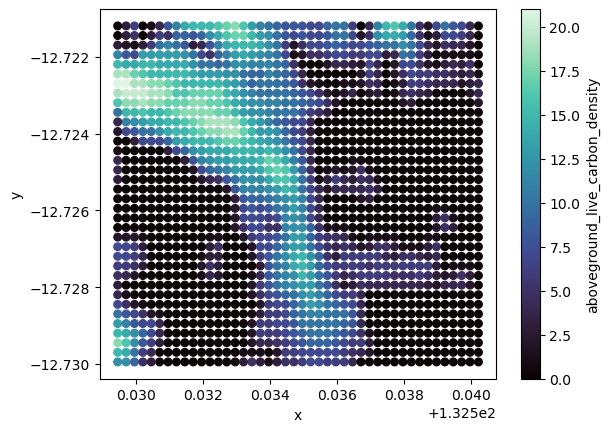

In [3]:
# Plot the data directly from pandas dataframe.
df.plot(x="x", y="y", # Plot latitude on y axis and longitude on x axis.
        kind="scatter", # Set the type of plot to be a scatter plot.
        s=30, # Set the marker size (higher numbers indicate larger markers).
        c="aboveground_live_carbon_density", # Set the variable to color the markers by. 
        colormap="mako", # Set the colormap.
        ) 

## Option 2: Plot from XArray. 
If you use XArray data formats for analysis, it may be convenient to plot from XArray rather than directly from the pandas DataFrame. The cell below demonstrates how the DataFrame could be converted to an XArray Dataset, using the columns 'year', 'x', and 'y' as the dataset dimensions.

Once the data is in an XArray Dataset, it can be plotted directly from the XArray object either using matplotlib's scatter optoin, or using XArray's default plotting functionality, which also uses matplotlib under the hood, but visualizes the data as a heatmap instead. 

Both these plotting options are well suited for working with the data in XArray format, but XArray's default plotting of the data as a heatmap may be better suited for visualizing raster data.

Note that we are not explicitly handling the CRS in these examples. Instead, the x and y coordinates are treated as simple cartesian coordinates. These visualizations are best used to get a quick overview of the data rather than for producing spatially accurate maps or visuals. 

In [4]:
# Set the columns to numeric type.
df[['y', 'x', 'aboveground_live_carbon_density']] = df[['y', 'x', 'aboveground_live_carbon_density']].apply(pd.to_numeric)

# Set dataframe indices before converting to xarray. 
data_df = df.set_index(['year','y', 'x'])
data_xarr = data_df.to_xarray()

# Visualize the format of the XArray Dataset
data_xarr

<xarray.Dataset> Size: 39kB
Dimensions:                          (year: 1, y: 36, x: 44)
Coordinates:
  * year                             (year) int16 2B 2020
  * y                                (y) float64 288B -12.73 -12.73 ... -12.72
  * x                                (x) float64 352B 132.5 132.5 ... 132.5
Data variables:
    aboveground_live_carbon_density  (year, y, x) float64 13kB 12.0 12.0 ... 0.0
    crs                              (year, y, x) object 13kB 'EPSG:4326' ......
    pixel_boundary                   (year, y, x) object 13kB 'POLYGON((132.5...

### Plot as scatter plot:

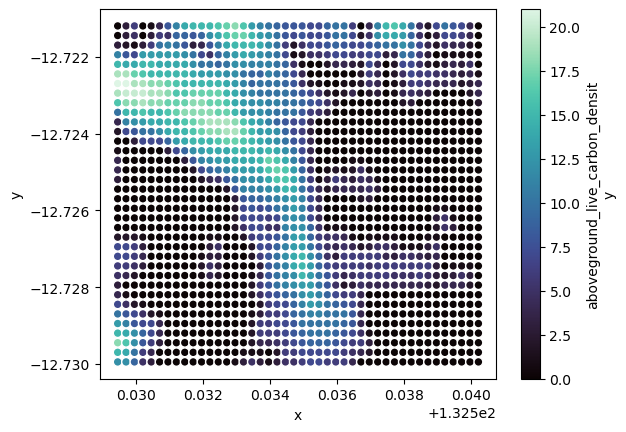

In [5]:
data_xarr.plot.scatter(x = "x", y = "y", # Plot latitude on y axis and longitude on x axis.
                       hue = "aboveground_live_carbon_density", # Set the variable to color the markers by. 
                       add_colorbar = True, # Add a colorbar to the plot.
                       s = 40, # Set the markersize (larger values indicate larger markers).
                       cmap = "mako") # Set the colormap.

### Plot as heatmap (XArray Default Plotting):

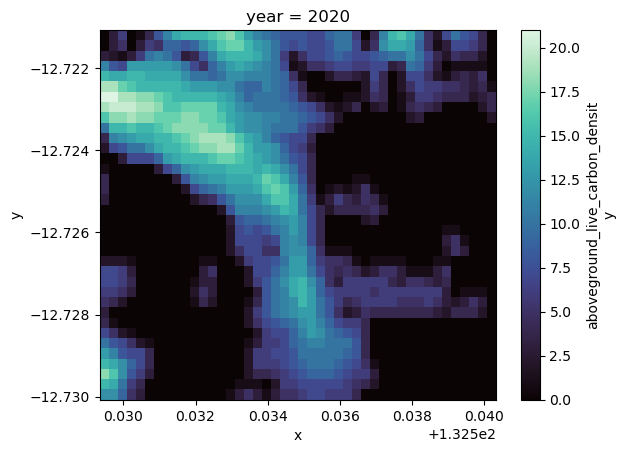

In [6]:
data_xarr['aboveground_live_carbon_density'].plot(cmap='mako')

## Option 3: Plot with Geopandas
If spatial accuracy and minimizing distortion is important for your use case, a plotting method like this may be better suited. This plotting method uses geopandas to create a GeoDataFrame of the data based on the pixel boundary that we converted to WKT format in our SQL query and the CRS of the dataset. This method plots each pixel boundary directly, meaning there is no distortion in the shape of the AOI or the pixels themselves. 

<Axes: >

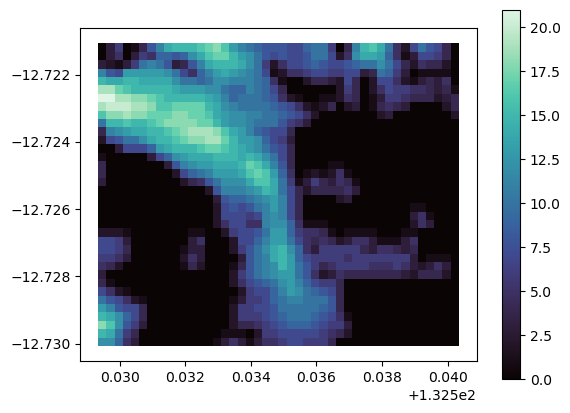

In [7]:
# Convert pandas dataframe to geodataframe and then plot using pixel boundary.
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["pixel_boundary"]), crs=df.iloc[0]["crs"])
gdf.plot("aboveground_live_carbon_density", cmap='mako', legend=True)

## Option 4: Plot with basemap from Cartopy.
This example demonstrates how to plot the data on top of a basemap using Cartopy. The data used in this example has a CRS of EPSG:4326. In Cartopy, we can represent EPSG:4326 using the `ccrs.PlateCarree()` projection. 

This example plots the data on top of an Open Street Map basemap. Feel free to adjust the parameters to customize the map to suit your use case. 

Note that this example first converts the data to an XArray dataset, as in Option 2.

In [8]:
# Set the columns to numeric type.
df[['y', 'x', 'aboveground_live_carbon_density']] = df[['y', 'x', 'aboveground_live_carbon_density']].apply(pd.to_numeric)

# Set dataframe indices before converting to xarray. 
data_df = df.set_index(['year','y', 'x'])
data_xarr = data_df.to_xarray()

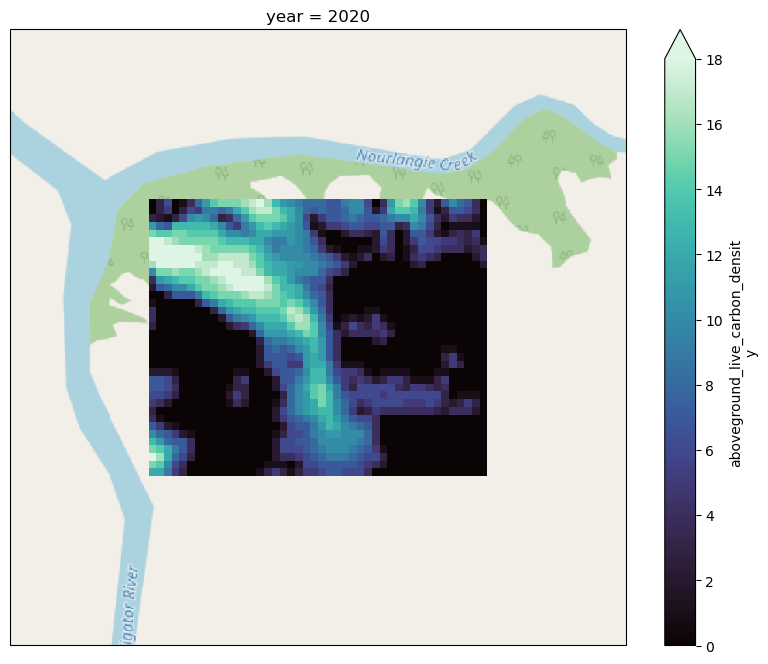

In [9]:
# Select OSM basemap imagery.
imagery = OSM()

# Set up matplotlib figure.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Calculate the center of the AOI.
lon = data_xarr.coords['x']
lat = data_xarr.coords['y']
lon_center = float(lon.mean())
lat_center = float(lat.mean())

# Set zoom factor (higher values zoom out more).
zoom_out_factor = 0.01

# Set map frame extent based on AOI and zoom factor.
extent = [lon_center - zoom_out_factor, lon_center + zoom_out_factor,
          lat_center - zoom_out_factor, lat_center + zoom_out_factor]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add the OSM basemap imagery to the map.
ax.add_image(imagery, 15)

# Plot the data onto the basemap.
data_xarr['aboveground_live_carbon_density'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),  
    cmap='mako',
    robust=True
)

# Show the plot
plt.show()

## Option 5: Interactive Plot with Folium

Like Option 3, this plotting method first converts the dataframe to a GeoDataFrame using Geopandas. The example below shows how to add two different basemaps, with interactive control to turn layers on and off. This sort of map can be viewed interactively within the Jupyter Notebook, or saved to an html file if desired. 

In [10]:
# Convert pandas dataframe to geodataframe based on the pixel boundary.
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["pixel_boundary"]), crs=df.iloc[0]["crs"])

In [11]:
# Find the centroid of the data to set the initial map location.
centroid = gdf.geometry.union_all().centroid

# Initialize map with no tiles.
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16, control_scale=True, tiles=None)

# Add satellite layer as the default basemap layer.
satellite = folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    name='Esri Satellite Imagery',
    attr='Esri',
    overlay=False,
    control=True,
    show=True  
).add_to(m)

# Add OpenStreetMap as an alternative basemap layer.
osm = folium.TileLayer(
    tiles="OpenStreetMap",
    name='Open Street Map',
    overlay=False,
    show=False  
).add_to(m)

# Create a linear colormap for the variable of interest.
colormap = cm.linear.inferno.scale(
    gdf["aboveground_live_carbon_density"].min(), 
    gdf["aboveground_live_carbon_density"].max()
)

# Define a simple function for applying the styling to the GeoJSON layer.
def style_function(feature):
    carbon_value = feature['properties']['aboveground_live_carbon_density']
    return {
        'fillColor': colormap(carbon_value), # Color of the pixel based on colormap.
        'color': 'black', # Border color of the pixel.
        'weight': 0.1, # Border weight of the pixel.
        'fillOpacity': 0.7 # Fill opacity of the pixel.
    }

# Convert your geodataframe to GeoJSON format to plot.
gdf_json = gdf.to_json()

# Add the geodataframe to the map as a GeoJSON layer.
folium.GeoJson(
    gdf_json,
    name="Aboveground Live Carbon Density",
    style_function=style_function, # Define the function to style each pixel.
    tooltip=folium.GeoJsonTooltip(
        fields=['aboveground_live_carbon_density'],
        aliases=['Aboveground Live Carbon Density:'],
        localize=True
    )
).add_to(m)

# Add colormap to the map.
colormap.caption = 'Aboveground Live Carbon Density'
colormap.add_to(m)

# Add control to turn layers on and off.
folium.LayerControl().add_to(m)

# Display the map.
m